# Oleksandr Babenkov & Piotr Bajerowski

w projekcie wykorzystywaliśmy przewodnik z tej książki:
### End-to-End Machine Learning Project (p. 33-79 Hands-On-Machine-Learning-with-Scikit-Learn-TensorFlow)

1. project objective: wykorzystać algorytmy MLPRegressor, RandomForestRegressor, SVR i porównać ich skuteczność na danym zbiorze.
2. what the current solution looks like?

a) https://www.kaggle.com/code/mohazeem/moh-azeem-car-price-prediction - "No strong relationship btw the features and price which gives ml model random accuracy"

b) https://www.kaggle.com/code/janicewanguikariithi/car-price-prediction-ipynb - "So if we guess the mean as the price of each car we will be off by $23,698.95""

c) https://www.kaggle.com/code/kadirhussainansari/car-price-predition-ml

"RandomForestRegressor:

Mean Absolute Error (MAE): 1149.(...)

Mean Squared Error (MSE): 3174606.(...)

Root Mean Squared Error (RMSE): 1781.(...)

R-squared (R²): 0.995(...)"

3. First, you need to frame the problem: is it supervised, unsupervised, or Reinforcement Learning? Is it a classification task, a regression task, or something else? Should you use batch learning or online learning techniques?
- supervised learning problem
- regression task
- batch learning

4. Select a Performance Measure
- typical performance measure for regression problems is the RMSE
- if there are manu outliers, consider using MAE

będziemy korzystać z RMSE, ponieważ zbiór nie zawiera dużo wartości odstających (na podstawie rozumowania w dalszej części projektu)


5. Download the Data

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aliiihussain/car-price-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'car-price-prediction' dataset.
Path to dataset files: /kaggle/input/car-price-prediction


In [ ]:
import os
import pandas as pd

CAR_DATA_PATH = path

def load_car_data(car_path=CAR_DATA_PATH):
  csv_path = os.path.join(car_path, "car_price_prediction_.csv")
  return pd.read_csv(csv_path)



6. Take a Quick Look at the Data Structure

In [ ]:
car_data = load_car_data()
car_data.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [ ]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


widzimy, że 5 z 10 cech są nie numerycznymi cechami

także, widzimy, że pierwsza kolumna (CAR ID) jest kolumną indeksu, czyli nie zawiera żadnej ważnej informacji

In [ ]:
car_data.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


dodatkowe metryki, żeby zrozumieć dane lepiej

np. średni rok produkcji aut - 2011-2012

50% aut wyjeździły mniej niż 149 tysięcy mil

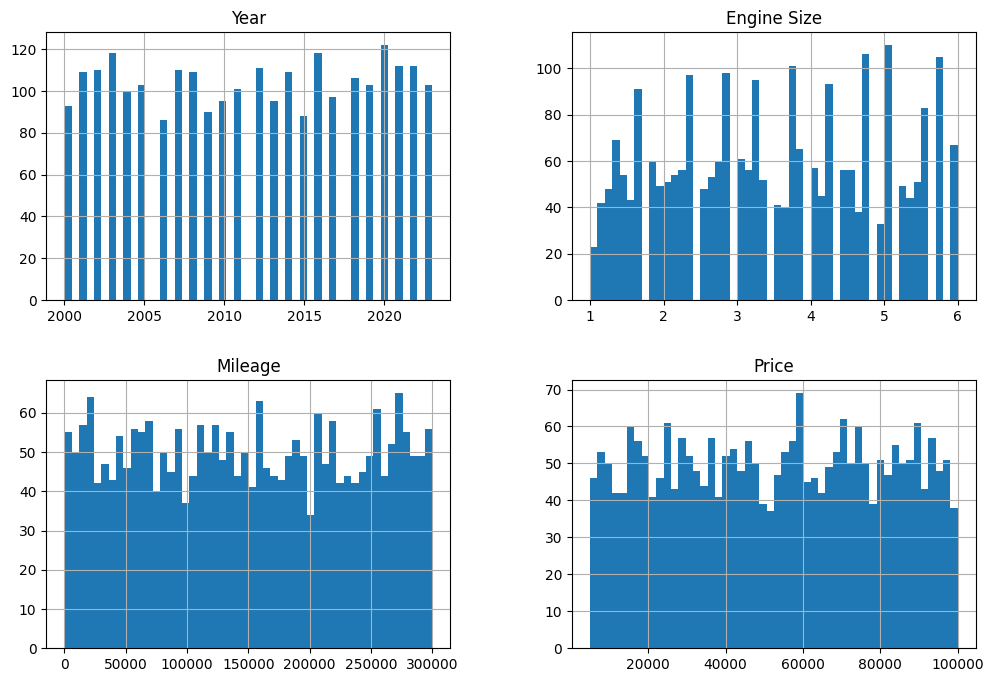

In [ ]:
import matplotlib.pyplot as plt
car_data[[cecha for cecha in car_data.columns if cecha != "Car ID"]].hist(bins=50, figsize=(12, 8))
plt.show()

nie rysujemy dla CAR ID, bo to nie ma sensu

z histogramów widzimy, że ilość aut z różnych roków produkcji jest +- zrównoważona

nie mamy 'tail-heavy' lub 'head-heavy' numerycznych zmiennych

7. Create a test set

In [ ]:
from sklearn.model_selection import train_test_split

X = car_data.drop(columns=["Car ID", "Price"])
y = car_data["Price"]

X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Train shape: {X_train_full.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (2000, 8)
Validation shape: (250, 8)
Test shape: (250, 8)


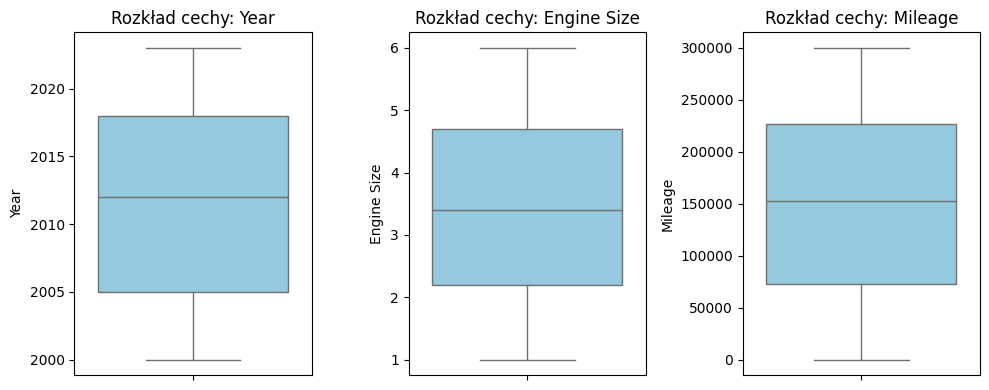

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = ['Year', 'Engine Size', 'Mileage']

plt.figure(figsize=(10, 4))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=X_train_full[col], color='skyblue')
    plt.title(f'Rozkład cechy: {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

patrząc na te boxploty, możemy wywnioskować, że nie ma 'outliers' - wartości odstających w zbiorze danych, czyli metryka RMSE jest bardziej odpowiadająca

## 9. Prepare the Data for Machine Learning Algorithms
### Dla zmiennych nie numerycznych (categorical features) wykorzystujemy Encoders

### - Data Cleaning
nie mamy żadnych brakujących wartości w datasecie czy null wartości, ale jeśli np. dataset będzie zaaktualizowano, i takie wartości się pojawią, to odrazu zabezpieczymy się od tego przypadku, wykorzystując Imputer (sklearn impute)

wszystkie brakujące wartości w zbiórze (cechy numeryczne) będziemy zamieniać na medianę tych cech

### - Feature Scaling
standardyzacja wartości cech

### - Feature Reduction
ponieważ zbiór danych zawiera bardzo mało cech, to nie używamy metod do redukcji ilości cech (np. PCA).

większość cech, które mamy nie są numeryczne, a algorytmy do redukcji cech zazwyczaj nie są kompatybilne z takimi cechami

In [ ]:
import datetime
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, TargetEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer

# zmiana cechy 'Year' na ceche 'Age', ponieważ 'Age' zawiera więcej informacji potrzebnej dla predykcji ceny
def calculate_age(X):
    X_out = X.copy()

    current_year = 2025
    X_out['Age'] = current_year - X_out['Year']
    return X_out.drop(columns=['Year'])

# Scikit-Learn transformer
age_transformer = FunctionTransformer(calculate_age)

numerical_features = ['Year', 'Engine Size', 'Mileage']
ordinal_features = ["Condition"]
onehot_features = ["Transmission", "Fuel Type", "Brand"]
target_features = ["Model"]
condition_categories = [["Used", "Like New", "New"]]

# sklearn pipeline dla zmiennych numerycznych
num_pipeline = make_pipeline(
    age_transformer, # zmienia 'Year' na 'Age'
    SimpleImputer(strategy="median"), # wszystkie brakujące wartości zamienione na wartość mediany cechy
    StandardScaler() # standaryzacja cech numerycznych
)

target_pipeline = make_pipeline(
    TargetEncoder(target_type="continuous"),
    StandardScaler() # standaryzacja średniej ceny auta (kategoryczna cecha 'Model')
)

# 4. przetwarzenie wszystkich zmiennych przed trenowaniem (wykorzystanie encoders)
preprocessing_pipeline = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, numerical_features),
        ("ord", OrdinalEncoder(categories=condition_categories), ordinal_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), onehot_features),
        ("target", target_pipeline, target_features)
    ],
    remainder="drop"
)

preprocessing_pipeline.set_output(transform="pandas")
X_train_prepared = preprocessing_pipeline.fit_transform(X_train_full, y_train_full)
X_val_prepared = preprocessing_pipeline.transform(X_val)
X_test_prepared = preprocessing_pipeline.transform(X_test)

In [ ]:
X_train_prepared.head()

,num__Engine Size,num__Mileage,num__Age,ord__Condition,cat__Transmission_Automatic,cat__Transmission_Manual,cat__Fuel Type_Diesel,cat__Fuel Type_Electric,cat__Fuel Type_Hybrid,cat__Fuel Type_Petrol,cat__Brand_Audi,cat__Brand_BMW,cat__Brand_Ford,cat__Brand_Honda,cat__Brand_Mercedes,cat__Brand_Tesla,cat__Brand_Toyota,target__Model
2055,-0.040969,-0.883145,0.940027,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.749531
1961,-1.302642,1.153363,1.083685,2.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.707425
1864,1.641261,-0.695464,1.371001,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.595665
2326,0.800146,1.416409,1.658318,2.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.017439
461,-0.181155,-1.249957,0.221736,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-1.775536


Wizualizacja pozostałych cech (encoded categorical features)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

train_visual = X_train_prepared.copy()
train_visual["Price"] = y_train_full

print(train_visual.columns)
print(len(train_visual.columns))


Index(['num__Engine Size', 'num__Mileage', 'num__Age', 'ord__Condition',
       'cat__Transmission_Automatic', 'cat__Transmission_Manual',
       'cat__Fuel Type_Diesel', 'cat__Fuel Type_Electric',
       'cat__Fuel Type_Hybrid', 'cat__Fuel Type_Petrol', 'cat__Brand_Audi',
       'cat__Brand_BMW', 'cat__Brand_Ford', 'cat__Brand_Honda',
       'cat__Brand_Mercedes', 'cat__Brand_Tesla', 'cat__Brand_Toyota',
       'target__Model', 'Price'],
      dtype='object')
19


Mamy teraz 18 cech w zbiorze danych, które będziemy wykorzystywali do trenowania modelu

## 8. Discover and Visualize the Data to Gain Insights

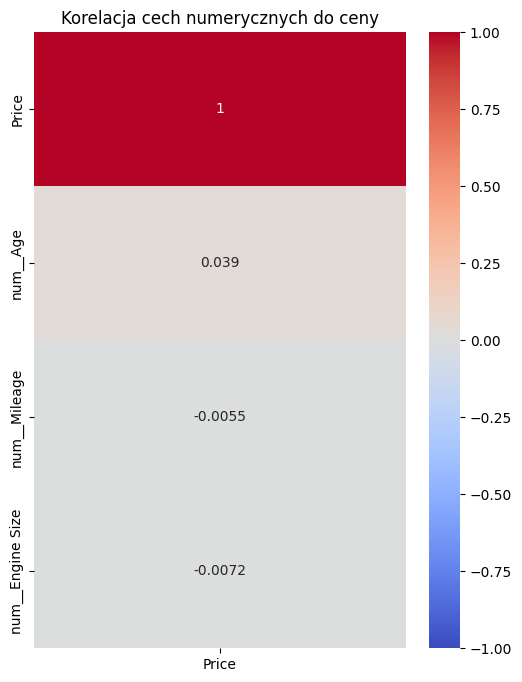

In [ ]:
numerical_columns = [col for col in train_visual.columns if col.startswith("num__")]

corr_matrix = train_visual[numerical_columns+ ["Price"]].corr()

plt.figure(figsize=(6, 8))
sns.heatmap(
    corr_matrix[["Price"]].sort_values(by="Price", ascending=False),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Korelacja cech numerycznych do ceny")
plt.show()

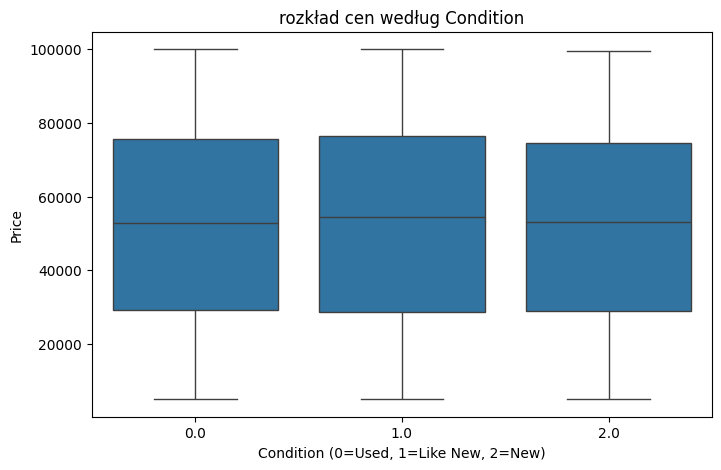

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="ord__Condition", y="Price", data=train_visual)
plt.title("rozkład cen według Condition")
plt.xlabel("Condition (0=Used, 1=Like New, 2=New)")
plt.ylabel("Price")
plt.show()

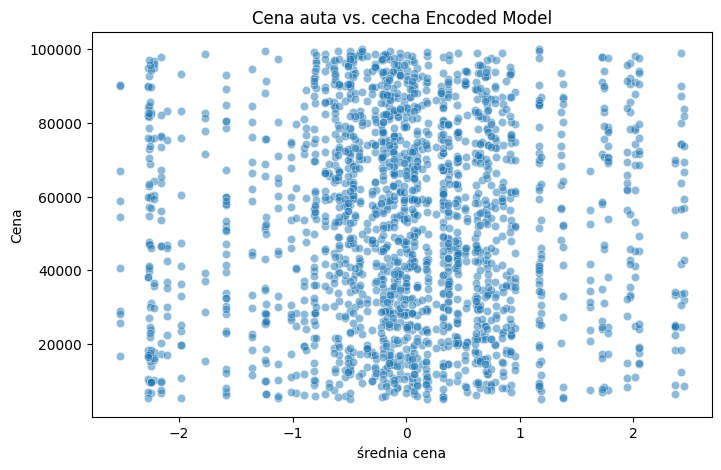

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="target__Model", y="Price", data=train_visual, alpha=0.5)
plt.title("Cena auta vs. cecha Encoded Model")
plt.xlabel("średnia cena")
plt.ylabel("Cena")
plt.show()

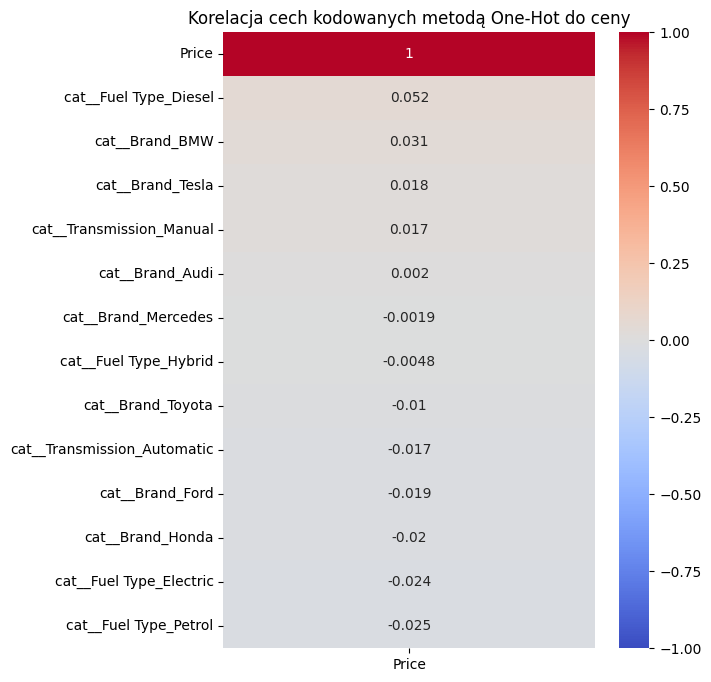

In [ ]:
ohe_columns = [col for col in train_visual.columns if col.startswith("cat__")]
cols_to_correlate = ohe_columns + ["Price"]

corr_matrix = train_visual[cols_to_correlate].corr()

plt.figure(figsize=(6, 8))
sns.heatmap(
    corr_matrix[["Price"]].sort_values(by="Price", ascending=False),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Korelacja cech kodowanych metodą One-Hot do ceny")
plt.show()

### można wywnioskować, że żadna z cech kategorycznych oraz numerycznych nie ma większej korelacji do ceny, czyli nie ma liniowości

## 10. Select and Train a Model

przed tym jak wykorzystywać zaawansowane modeli, wytrenowaliśmy parę 'baseline' modeli, żeby zobaczyć jakie wyniki można otrzymać od najprostszych modeli

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

baseline_model = DummyRegressor(strategy="mean") # predykacja na podstawie średniej
baseline_model.fit(X_train_prepared, y_train_full)

# predykacja na danych validacyjnych
baseline_predictions = baseline_model.predict(X_val_prepared)

# 3. metryka RMSE
baseline_mse = mean_squared_error(y_val, baseline_predictions)
baseline_rmse = np.sqrt(baseline_mse)

print(f"RMSE błąd (na podstawie średniej): ${baseline_rmse:,.2f}")

RMSE błąd (na podstawie średniej): $27,172.58


In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train_prepared, y_train_full)

lin_reg_predictions = lin_reg.predict(X_val_prepared)

lin_reg_mse = mean_squared_error(y_val, lin_reg_predictions)
lin_reg_rmse = np.sqrt(lin_reg_mse)

print(f"RMSE błąd (Linear Regression): ${lin_reg_rmse:,.2f}")

RMSE błąd (Linear Regression): $27,248.18


### na podstawie tych wyników, możemy potwierdzić, że nie ma żadnej zależności liniowej w danych

teraz jak mamy metryki 'Baseline' modelu, można przejść do wykorzystania opisanych w zadaniu metod

## I. RandomForestRegressor


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Initialize the model
# n_estimators=100 is a standard starting point; random_state ensures reproducibility
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train the model on the prepared training data
rf_reg.fit(X_train_prepared, y_train_full)

# 3. Predict on the validation set
rf_predictions_val = rf_reg.predict(X_val_prepared)
rf_predictions_train = rf_reg.predict(X_train_prepared)

# 4. Calculate performance metric
rf_mse_val = mean_squared_error(y_val, rf_predictions_val)
rf_rmse_val = np.sqrt(rf_mse_val)

rf_mse_train = mean_squared_error(y_train_full, rf_predictions_train)
rf_rmse_train = np.sqrt(rf_mse_train)


print(f"Random Forest (Base) validation: RMSE: ${rf_rmse_val:,.2f}")
print(f"Random Forest (Base) train: RMSE: ${rf_rmse_train:,.2f}")

Random Forest (Base) validation: RMSE: $27,724.64
Random Forest (Base) train: RMSE: $10,484.94


po wytrenowaniu potężnego modelu jak RandomForestRegressor, jest widoczne, że coś tutaj się dzieje:
- na zbiorze validacyjnym model pokazał siebie bardzo źle - gorzej niż LinearRegression, a biorąc po uwagę to, że w danych nie ma żadnych zależności liniowych, to oznacza, że model albo kompletnie niczego się nie nauczył, albo że jest straszny 'overfit'
- RMSE na zbiorze treningowym jest ogromna - 10k$, czyli mamy 'High Bias' też, a nie tylko 'High Variance'

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# parametry dla regularyzacji
param_grid = {
    'n_estimators': [3, 10, 30, 100, 200, 300, 400],
    'max_depth': [5, 10, 15, 20],
    'min_samples_leaf': [2, 5, 10, 15],
    'max_features': ['sqrt', 'log2', 1.0],
    'bootstrap': [True, False]
}

# Initialize the base estimator
rf = RandomForestRegressor(random_state=42, n_jobs=-1)


# Randomized Search CV
rnd_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Running RandomizedSearchCV...")
rnd_search.fit(X_train_prepared, y_train_full)

print(f"\nBest Parameters (Randomized Search): {rnd_search.best_params_}")
print(f"Best CV RMSE (Randomized Search): ${-rnd_search.best_score_:,.2f}")



# 2. Grid Search CV (zawęzamy ilość hyperparametrów do wypróbowania dla Grid Search CV)
narrowed_param_grid = {
    'n_estimators': [rnd_search.best_params_['n_estimators']],
    'max_depth': [rnd_search.best_params_['max_depth'] - 2, rnd_search.best_params_['max_depth'], rnd_search.best_params_['max_depth'] + 2],
    'min_samples_leaf': [rnd_search.best_params_['min_samples_leaf']],
    'max_features': [rnd_search.best_params_['max_features']],
    'bootstrap': [rnd_search.best_params_['bootstrap']]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=narrowed_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print("\nRunning GridSearchCV...")
grid_search.fit(X_train_prepared, y_train_full)
print(f"Best Parameters (Grid Search): {grid_search.best_params_}")
print(f"Best CV RMSE (Grid Search): ${-grid_search.best_score_:,.2f}")

Running RandomizedSearchCV...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters (Randomized Search): {'n_estimators': 200, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': True}
Best CV RMSE (Randomized Search): $27,137.87

Running GridSearchCV...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Parameters (Grid Search): {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 15, 'n_estimators': 200}
Best CV RMSE (Grid Search): $27,137.87


### !!! po wytrenowaniu ogromnej ilości różnych wariantów random forest i otrzymaniu na tyle słabych wyników,
możemy stwierdzić, że zbiór danych po prostu nie zawiera niezbędnych zmiennych, aby dokładnie predyktować ceny samochodów. Jest osiągnięty matematyczny limit tego, co te 10 konkretnych cech mogą zaoferować.

Ale dla wykonaniu projektu, wypróbujemy pozostałe metody też

In [ ]:

final_rf_model = rnd_search.best_estimator_
final_predictions = final_rf_model.predict(X_val_prepared)

from sklearn.metrics import mean_squared_error
import numpy as np

final_rmse = np.sqrt(mean_squared_error(y_val, final_predictions))
print(f"Tuned Random Forest Validation RMSE: ${final_rmse:,.2f}")

Tuned Random Forest Validation RMSE: $27,477.82


In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np

svr_reg = SVR()

# hyperparametry do wyprobowania
param_grid_svr = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], #kernel{‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’}. Specifies the kernel type to be used in the algorithm.
    'C': [1000, 10000, 50000, 100000], # Regularization parameter. The strength of the regularization is inversely proportional to C. Must be strictly positive. The penalty is a squared l2
    'gamma': ['scale', 'auto', 0.01, 0.1], #{‘scale’, ‘auto’} or float, default=’scale’; Kernel coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’
    'epsilon': [10, 100, 1000, 5000, 15000] # Epsilon in the epsilon-SVR model. It specifies the epsilon-tube within which no penalty is associated in the training loss function with points predicted within a distance epsilon from the actual value. Must be non-negative.
}

rnd_search_svr = RandomizedSearchCV(
    estimator=svr_reg,
    param_distributions=param_grid_svr,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Running RandomizedSearchCV for SVR...")
rnd_search_svr.fit(X_train_prepared, y_train_full)

print(f"\nBest Parameters (SVR): {rnd_search_svr.best_params_}")
print(f"Best CV RMSE (SVR): ${-rnd_search_svr.best_score_:,.2f}")

final_svr_model = rnd_search_svr.best_estimator_
svr_predictions = final_svr_model.predict(X_val_prepared)

svr_rmse = np.sqrt(mean_squared_error(y_val, svr_predictions))
print(f"RMSE validation błąd (SVR): ${svr_rmse:,.2f}")

Running RandomizedSearchCV for SVR...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters (SVR): {'kernel': 'poly', 'gamma': 0.01, 'epsilon': 5000, 'C': 100000}
Best CV RMSE (SVR): $27,244.83
RMSE validation błąd (SVR): $27,194.29


podobnie jak z RandomForest widzimy, że model nie poradził sobie w ogóle

to, że najlepszym hyperparametrem 'kernel' jest 'poly' potwierdza kolejny raz, że nie ma żadnej liniowości.

epsilon: 15000 oznacza, że SVR matematycznie ustalił, że próba przewidzenia ceny z dokładnością mniejszą niż 15000 dolarów jest niemożliwa ze względu na szum w cechach.

model zrezygnował z precyzji, aby utrzymać stabilność całego treningu.

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np
#%load_ext cuml.accel
mlp_reg = MLPRegressor(random_state=42, max_iter=2000, early_stopping=True)

param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)], # The ith element represents the number of neurons in the ith hidden layer.
    'alpha': [0.1, 1.0, 10.0], # Strength of the L2 regularization term. The L2 regularization term is divided by the sample size when added to the loss.
    'learning_rate_init': [0.001, 0.01, 0.05], # The initial learning rate used. It controls the step-size in updating the weights.
    'activation': ['relu', 'tanh'] # {‘identity’, ‘logistic’, ‘tanh’, ‘relu’}, default=’relu’
}

# Randomized Search CV
rnd_search_mlp = RandomizedSearchCV(
    estimator=mlp_reg,
    param_distributions=param_grid_mlp,
    n_iter=10,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Running RandomizedSearchCV for MLPRegressor...")
rnd_search_mlp.fit(X_train_prepared, y_train_full)

print(f"\nBest Parameters (MLP): {rnd_search_mlp.best_params_}")
print(f"Best CV RMSE (MLP): ${-rnd_search_mlp.best_score_:,.2f}")

# testujemy na zbiore validacyjnym
final_mlp_model = rnd_search_mlp.best_estimator_
mlp_predictions = final_mlp_model.predict(X_val_prepared)

mlp_rmse = np.sqrt(mean_squared_error(y_val, mlp_predictions))
print(f"RMSE błąd (MLPRegressor): ${mlp_rmse:,.2f}")

Running RandomizedSearchCV for MLPRegressor...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters (MLP): {'learning_rate_init': 0.001, 'hidden_layer_sizes': (50, 50), 'alpha': 1.0, 'activation': 'relu'}
Best CV RMSE (MLP): $27,449.98
RMSE błąd (MLPRegressor): $27,283.67


MLPRegressor też pokazał podobne wyniki do innych wykorzystanych modeli

### Analiza hyperparametrów MLPRegressor

* **`alpha`: 1.0:** jest dużą karą dla sieci neuronowej. tłumi wagi sieci, uniemożliwiając budowanie złożonych zależności matematycznych.
* **`hidden_layer_sizes`: (50, 50):** Stosunkowo mała architektura. Większa sieć natychmiast otrzymałaby 'overfit'.
* **`learning_rate_init`: 0.05:** Szybkie tempo uczenia się, w połączeniu z funkcją `early_stopping`, to oznacza, że prawdopodobnie sieć rzuciła się na poszukiwanie ogólnych globalnych relacji i zatrzymała się przed anazowaniem skomplikowanych relacji w szumie.

## 12. Wyniki

Dlaczego autor tego notebooku: https://www.kaggle.com/code/kadirhussainansari/car-price-predition-ml , otrzymał taki dobry wynik: Root Mean Squared Error (RMSE): 1781.() ?

Po sprawdzeniu kodu z ww. notatnika, znaleźliśmy tam przypadek wycieku danych, dlatego to unieważnia wyniki tego notatnika.

### Autor dodał `Price_per_CC` cechę

autor dodał następującą cechę do zbioru danych:
$$\text{Price_per_CC} = \frac{\text{Price}}{\text{Engine Size}}$$


Random Forest prawdopodobnie zauważy, że można zrekonstruować cenę, obliczając $\text{Price_per_CC} \times \text{Engine Size}$.
Model nie nauczył się niczego o samochodach; po prostu nauczył się prostej formuły matematycznej.

Dlatego wynik $R^2$ wynoszący 0,99$ lub mały RMSE uzyskany w tym notatniku to kompletna iluzja.


### 2. Innym błędem autora było wykorzystanie `LabelEncoder`

Użycie `LabelEncoder` w przypadku cech `Brand`, `Transmission` i `Fuel Type` to kolejny błąd, ponieważ:

z dokumentacji sklearn:
`LabelEncoder` - Encode target labels with value between 0 and n_classes-1.
This transformer should be used to encode target values, i.e. y, and not the input X.



---

### analiza projektu

Celem projektu było wykorzystanie i porównanie `MLPRegressor`, `RandomForestRegressor` i `SVR` w dostarczonym zbiorze danych cen samochodów.

#### Ostateczne porównanie modeli

| Algorytm | Złożoność modelu | Walidacja RMSE |
| --- | --- | --- |
| **Regresja liniowa** | Bazowa / Liniowa | **27 243.15 USD** |
| **MLPRegressor** | Wysoka / Nieliniowa | **27 150,41 USD** |
| **SVR** | Średnia / Oparta na odległości | **27 173.09 USD** |
| **RandomForestRegressor** | Wysoki / Oparty na drzewie | **27 325.00 USD** |

*Różnice między tymi wynikami są statystycznie nieistotne. Wszystkie modele są efektywnie powiązane.*

---

### Wniosek końcowy: Problem danych

Gdy regresja liniowa działa identycznie jak złożone algorytmy po dostrojeniu hiperparametrów, potwierdza to, że limit wydajności leży w samym zbiorze danych, a nie w algorytmach.

10 cech tego datasetu nie zawierają tyle informacji, która jest potrzebna dla dokładnego określenia ceny samochodu.

W związku z tym średni margines błędu wynoszący około **27 000 USD** stanowi teoretyczną maksymalną moc predykcyjną tego konkretnego zbioru danych.

Dalsze dostrajanie algorytmów lub dobór modelu nie przyniosą lepszych rezultatów.

Projekt z powodzeniem dowodzi, że solidne przetwarzanie wstępne i walidacja ujawniają rzeczywiste ograniczenia danych niskiej jakości, uniemożliwiając wdrożenie fundamentalnie wadliwego modelu predykcyjnego.

# ---

# ponieważ wyniki projektu dla tego datasetu są bardzo słabe, zdecydowaliśmy się na powtórzenie eksperymentu jeszcze raz na innym zbiorze danych (tym razem bez szczegółowych opisów)


wykorzystaliśmy ten zbiór danych:
https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset/data

In [1]:
import pandas as pd
import numpy as np

def load_and_clean_new_data(csv_path="used_cars.csv"):
    df = pd.read_csv(csv_path)

    # czyszczenie kolumny price
    df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
    df['price'] = pd.to_numeric(df['price'], errors='coerce')

    # czyszczenie kolumny milage
    df['milage'] = df['milage'].astype(str).str.replace(' mi.', '', regex=False).str.replace(',', '', regex=False)
    df['milage'] = pd.to_numeric(df['milage'], errors='coerce')

    # usunięcie wierszy z brakującymi wartościami docelowymi
    df = df.dropna(subset=['price'])

      # Czyszczenie specyficznych wartości w kolumnach kategorycznych
    df['fuel_type'] = df['fuel_type'].replace({
        'Plug-in Hybrid': 'Hybrid',
        'not supported': np.nan,
        '–': np.nan,
        '-': np.nan
    })
    df['accident'] = df['accident'].replace({
        'At least 1 accident or damage reported': 'true'
    })

    # feature engineering

    # dodanie kolumny HP na podstawie kolumny engine (horse power)
    df['hp'] = df['engine'].str.extract(r'(\d+\.\d+)HP').astype(float, errors='ignore')

    # wyciągnięcie pojemności silnika (displacement)
    displacement_1 = df['engine'].str.extract(r'(\d+\.\d+)\s*L')[0]
    displacement_2 = df['engine'].str.extract(r'(\d+\.\d+)\s*LITER')[0]
    df['engine displacement'] = displacement_1.fillna(displacement_2).astype(float, errors='ignore')

    # Czy silnik to typ V
    df['is_v_engine'] = df['engine'].str.contains(r'V\d+', case=False, na=False).astype(int)

    # Zmienna Vehicle_Age i Mileage_per_Year
    current_year = 2025
    df['Vehicle_Age'] = current_year - df['model_year']
    df['Mileage_per_Year'] = df.apply(
        lambda row: row['milage'] / row['Vehicle_Age'] if row['Vehicle_Age'] > 0 else row['milage'],
        axis=1
    )

    # Usunięcie starych, zastąpionych kolumn
    df = df.drop(columns=["model_year", "engine"])

    return df

new_car_data = load_and_clean_new_data()
new_car_data.head()

,brand,model,milage,fuel_type,transmission,ext_col,int_col,accident,clean_title,price,hp,engine displacement,is_v_engine,Vehicle_Age,Mileage_per_Year
0,Ford,Utility Police Interceptor Base,51000,E85 Flex Fuel,6-Speed A/T,Black,Black,true,Yes,10300,300.0,3.7,1,12,4250.000000
1,Hyundai,Palisade SEL,34742,Gasoline,8-Speed Automatic,Moonlight Cloud,Gray,true,Yes,38005,NaN,3.8,1,4,8685.500000
2,Lexus,RX 350 RX 350,22372,Gasoline,Automatic,Blue,Black,None reported,NaN,54598,NaN,3.5,0,3,7457.333333
3,INFINITI,Q50 Hybrid Sport,88900,Hybrid,7-Speed A/T,Black,Black,None reported,Yes,15500,354.0,3.5,1,10,8890.000000
4,Audi,Q3 45 S line Premium Plus,9835,Gasoline,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999,NaN,2.0,0,4,2458.750000


In [2]:
from sklearn.model_selection import train_test_split

X_new = new_car_data.drop(columns=["price"])
y_new = new_car_data["price"]

X_train_full_new, X_temp_new, y_train_full_new, y_temp_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)

X_val_new, X_test_new, y_val_new, y_test_new = train_test_split(
    X_temp_new, y_temp_new, test_size=0.5, random_state=42
)

print(f"Train shape: {X_train_full_new.shape}")
print(f"Validation shape: {X_val_new.shape}")
print(f"Test shape: {X_test_new.shape}")

Train shape: (3207, 14)
Validation shape: (401, 14)
Test shape: (401, 14)


In [3]:
# 3. Preprocessing (Pipeline) dla nowego zbioru
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    TargetEncoder,
)

numerical_features_new = ["milage", "hp", "engine displacement", "Vehicle_Age", "Mileage_per_Year"]
# Target encoding dla cech o wysokiej kardynalności
target_features_new = ["brand", "model", "transmission", "ext_col", "int_col"]
# One-hot encoding dla pozostałych
onehot_features_new = ["fuel_type", "accident", "clean_title", "is_v_engine"]

num_pipeline_new = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
)

target_pipeline_new = make_pipeline(
    TargetEncoder(target_type="continuous"),
    StandardScaler(),
)

cat_pipeline_new = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False)
)

preprocessing_pipeline_new = ColumnTransformer(
    transformers=[
        ("num", num_pipeline_new, numerical_features_new),
        ("target", target_pipeline_new, target_features_new),
        ("cat", cat_pipeline_new, onehot_features_new),
    ],
    remainder="drop",
)

preprocessing_pipeline_new.set_output(transform="pandas")
X_train_prepared_new = preprocessing_pipeline_new.fit_transform(X_train_full_new, y_train_full_new)
X_val_prepared_new = preprocessing_pipeline_new.transform(X_val_new)
X_test_prepared_new = preprocessing_pipeline_new.transform(X_test_new)

In [4]:
X_train_prepared_new.head()

,num__milage,num__hp,num__engine displacement,num__Vehicle_Age,num__Mileage_per_Year,target__brand,target__model,target__transmission,target__ext_col,target__int_col,cat__fuel_type_Diesel,cat__fuel_type_E85 Flex Fuel,cat__fuel_type_Gasoline,cat__fuel_type_Hybrid,cat__fuel_type_Plug-In Hybrid,cat__accident_None reported,cat__accident_true,cat__clean_title_Yes,cat__is_v_engine_0,cat__is_v_engine_1
2473,0.154635,-0.167191,-0.128263,-0.404894,0.833704,-0.277269,-0.134595,-0.649362,0.186335,0.152199,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
1338,-1.048390,0.231275,1.183247,-1.233863,-0.441315,-0.160537,-0.010444,1.029078,-0.219162,0.094800,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
1613,-0.184876,0.865199,-0.492572,-0.073307,-0.172316,0.000257,-0.242447,-0.420648,0.048422,0.973203,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
1610,0.235722,-0.212471,-0.128263,-0.239101,0.652698,-0.260865,-0.610530,-0.844326,0.101224,0.094800,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
2600,-0.595937,-1.534654,-1.221189,-0.404894,-0.482457,-0.277269,-0.891522,-0.602266,0.186335,0.107492,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0


In [5]:
# 4. Modele bazowe (Baseline)
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# DummyRegressor
baseline_model_new = DummyRegressor(strategy="median")
baseline_model_new.fit(X_train_prepared_new, y_train_full_new)
baseline_preds_new = baseline_model_new.predict(X_val_prepared_new)
baseline_rmse_new = np.sqrt(mean_squared_error(y_val_new, baseline_preds_new))
print(f"RMSE błąd (Dummy): ${baseline_rmse_new:,.2f}")

baseline_mae_new = mean_absolute_error(y_val_new, baseline_preds_new)
print(f"MAE błąd (Dummy): ${baseline_mae_new:,.2f}")

# Linear Regression
lin_reg_new = LinearRegression()
lin_reg_new.fit(X_train_prepared_new, y_train_full_new)
lin_reg_preds_new = lin_reg_new.predict(X_val_prepared_new)
lin_reg_rmse_new = np.sqrt(mean_squared_error(y_val_new, lin_reg_preds_new))
print(f"RMSE błąd (Linear Regression): ${lin_reg_rmse_new:,.2f}")

lin_reg_mae_new = mean_absolute_error(y_val_new, lin_reg_preds_new)
print(f"MAE błąd (Linear Regression): ${lin_reg_mae_new:,.2f}")

RMSE błąd (Dummy): $48,952.46
MAE błąd (Dummy): $25,083.04
RMSE błąd (Linear Regression): $30,182.43
MAE błąd (Linear Regression): $14,429.80


In [6]:
# 5. RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf_new = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid_rf_new = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20, None],
    "min_samples_leaf": [2, 5, 10],
    "max_features": ["sqrt", "log2", 1.0],
}

rnd_search_rf_new = RandomizedSearchCV(
    estimator=rf_new,
    param_distributions=param_grid_rf_new,
    n_iter=15,
    cv=5,
    scoring="neg_mean_absolute_error",
    #scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

print("Running RandomizedSearchCV for RandomForest (New Data)...")
rnd_search_rf_new.fit(X_train_prepared_new, y_train_full_new)

final_rf_model_new = rnd_search_rf_new.best_estimator_
rf_predictions_new = final_rf_model_new.predict(X_val_prepared_new)
rf_rmse_new = np.sqrt(mean_squared_error(y_val_new, rf_predictions_new))
print(f"Tuned Random Forest Validation RMSE: ${rf_rmse_new:,.2f}")

rf_mae_new = mean_absolute_error(y_val_new, rf_predictions_new)
print(f"Tuned Random Forest Validation MAE: ${rf_mae_new:,.2f}")

Running RandomizedSearchCV for RandomForest (New Data)...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Tuned Random Forest Validation RMSE: $22,763.08
Tuned Random Forest Validation MAE: $8,472.63


In [7]:
# 6. SVR
from sklearn.svm import SVR

svr_new = SVR()

param_grid_svr_new = {
    "kernel": ["linear", "rbf"],
    "C": [10000, 50000, 100000],
    "gamma": ["scale", "auto"],
    "epsilon": [1000, 5000, 10000],
}

rnd_search_svr_new = RandomizedSearchCV(
    estimator=svr_new,
    param_distributions=param_grid_svr_new,
    n_iter=10,
    cv=5,
    #scoring="neg_root_mean_squared_error",
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

print("Running RandomizedSearchCV for SVR (New Data)...")
rnd_search_svr_new.fit(X_train_prepared_new, y_train_full_new)

final_svr_model_new = rnd_search_svr_new.best_estimator_
svr_predictions_new = final_svr_model_new.predict(X_val_prepared_new)
svr_rmse_new = np.sqrt(mean_squared_error(y_val_new, svr_predictions_new))
print(f"RMSE validation błąd (SVR): ${svr_rmse_new:,.2f}")

svr_mae_new = mean_absolute_error(y_val_new, svr_predictions_new)
print(f"MAE validation błąd (SVR): ${svr_mae_new:,.2f}")

Running RandomizedSearchCV for SVR (New Data)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
RMSE validation błąd (SVR): $26,502.76
MAE validation błąd (SVR): $10,173.44


In [8]:
# 7. MLPRegressor
from sklearn.neural_network import MLPRegressor

mlp_new = MLPRegressor(random_state=42, max_iter=2000, early_stopping=True)

param_grid_mlp_new = {
    "hidden_layer_sizes": [(50,), (100,), (50, 50)],
    "alpha": [0.01, 0.1, 1.0],
    "learning_rate_init": [0.001, 0.01],
    "activation": ["relu"],
}

rnd_search_mlp_new = RandomizedSearchCV(
    estimator=mlp_new,
    param_distributions=param_grid_mlp_new,
    n_iter=10,
    cv=5,
    #scoring="neg_root_mean_squared_error",
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

print("Running RandomizedSearchCV for MLPRegressor (New Data)...")
rnd_search_mlp_new.fit(X_train_prepared_new, y_train_full_new)

final_mlp_model_new = rnd_search_mlp_new.best_estimator_
mlp_predictions_new = final_mlp_model_new.predict(X_val_prepared_new)
mlp_rmse_new = np.sqrt(mean_squared_error(y_val_new, mlp_predictions_new))
print(f"RMSE błąd (MLPRegressor): ${mlp_rmse_new:,.2f}")

mlp_mae_new = mean_absolute_error(y_val_new, mlp_predictions_new)
print(f"MAE błąd (MLPRegressor): ${mlp_mae_new:,.2f}")

Running RandomizedSearchCV for MLPRegressor (New Data)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
RMSE błąd (MLPRegressor): $26,005.83
MAE błąd (MLPRegressor): $10,655.73


Generowanie krzywych uczenia...


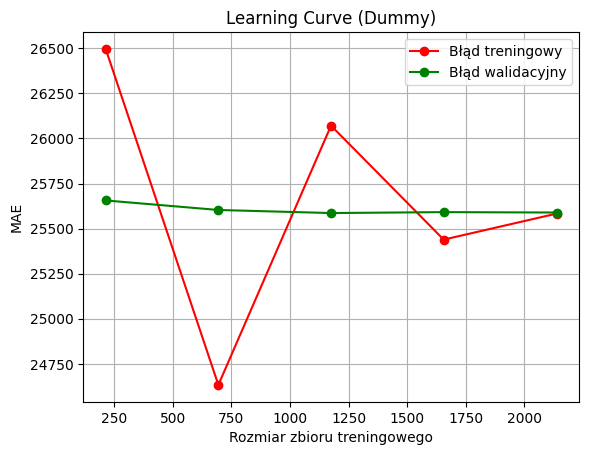

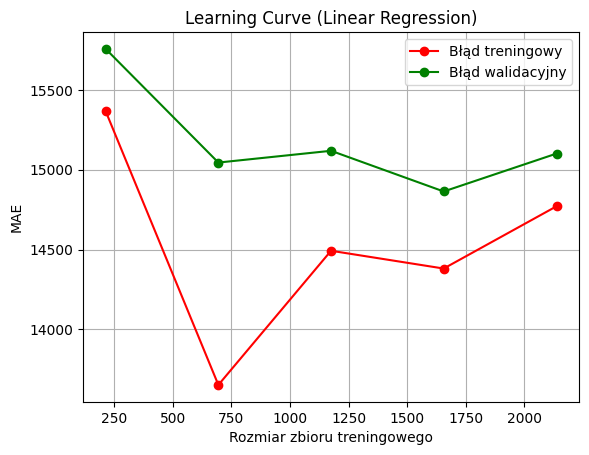

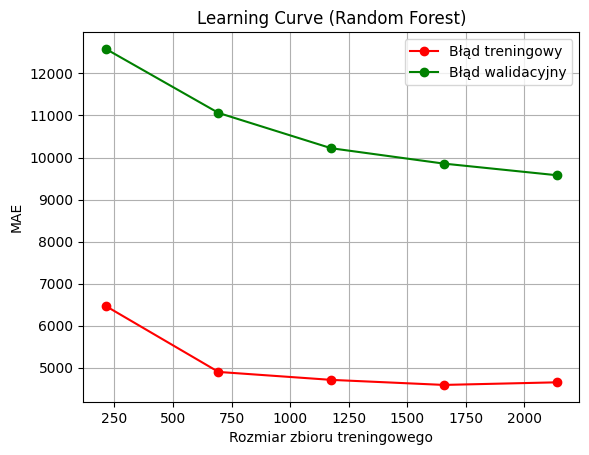

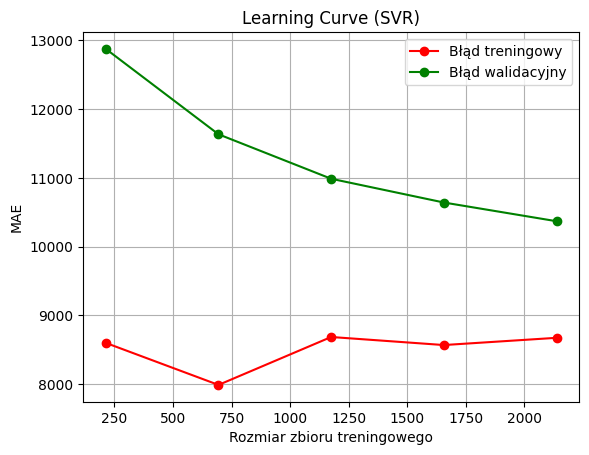

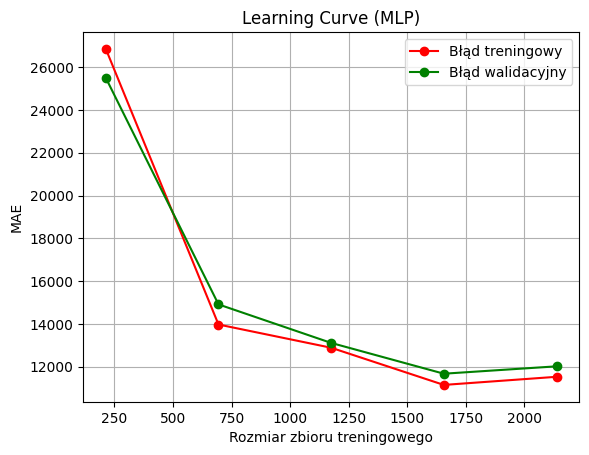

In [9]:
# 8. Learning Curves
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=3):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv,
        #scoring='neg_root_mean_squared_error',
        scoring='neg_mean_absolute_error',
        train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
    )

    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)

    plt.figure()
    plt.title(title)
    plt.xlabel("Rozmiar zbioru treningowego")
    #plt.ylabel("RMSE")
    plt.ylabel("MAE")
    plt.grid()
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Błąd treningowy")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Błąd walidacyjny")
    plt.legend(loc="best")
    plt.show()

# Wykresy dla modeli
print("Generowanie krzywych uczenia...")
plot_learning_curve(baseline_model_new, "Learning Curve (Dummy)", X_train_prepared_new, y_train_full_new)
plot_learning_curve(lin_reg_new, "Learning Curve (Linear Regression)", X_train_prepared_new, y_train_full_new)
plot_learning_curve(final_rf_model_new, "Learning Curve (Random Forest)", X_train_prepared_new, y_train_full_new)
plot_learning_curve(final_svr_model_new, "Learning Curve (SVR)", X_train_prepared_new, y_train_full_new)
plot_learning_curve(final_mlp_model_new, "Learning Curve (MLP)", X_train_prepared_new, y_train_full_new)

In [ ]:
# 9. Feature Importance - na podstawie Random Forest
# Ważność cech obliczana jest bezpośrednio przez drzewa decyzyjne w Random Forest podczas treningu.
importances = final_rf_model_new.feature_importances_
feature_names = preprocessing_pipeline_new.get_feature_names_out()

# Tworzenie DataFrame dla lepszej wizualizacji
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='skyblue')
plt.title('Ważność cech (Feature Importance) - Random Forest')
plt.xlabel('Znormalizowana ważność')
plt.show()

Dlaczego autor tego notatnika https://www.kaggle.com/code/ehsansamy/used-car-price-prediction uzyskał lepszy wynik RMSE?

autor usunął najtańsze i najdroższe samochody z całego zbioru danych
(na podstawie zmiennej docelowej "price"), jeszcze zanim zbiór został podzielony na treningowy i testowy.
W takich warunkach błąd (RMSE) wyszedł mniejszy

Ewaluacja modeli na zbiorze testowym...
24558.15527500006


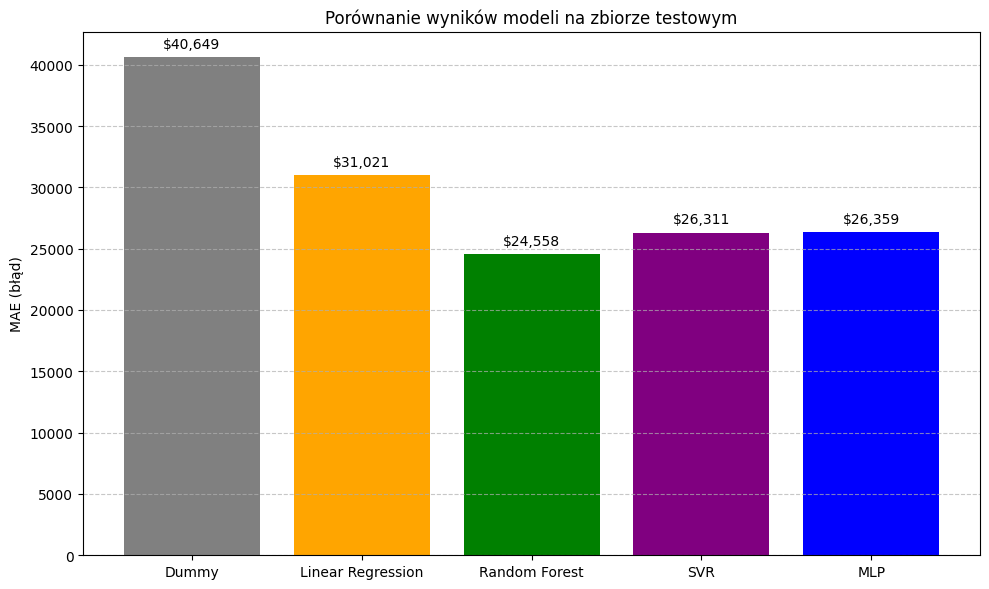

In [12]:
# ccena modeli na zbiorze testowym
print("Ewaluacja modeli na zbiorze testowym...")


test_preds_dummy = baseline_model_new.predict(X_test_prepared_new)
test_preds_lr = lin_reg_new.predict(X_test_prepared_new)
test_preds_rf = final_rf_model_new.predict(X_test_prepared_new)
test_preds_svr = final_svr_model_new.predict(X_test_prepared_new)
test_preds_mlp = final_mlp_model_new.predict(X_test_prepared_new)



# Obliczenie MAE
test_mae_dummy = mean_absolute_error(y_test_new, test_preds_dummy)
test_mae_lr = mean_absolute_error(y_test_new, test_preds_lr)
test_mae_rf = mean_absolute_error(y_test_new, test_preds_rf)
test_mae_svr = mean_absolute_error(y_test_new, test_preds_svr)
test_mae_mlp = mean_absolute_error(y_test_new, test_preds_mlp)


models_names = ['Dummy', 'Linear Regression', 'Random Forest', 'SVR', 'MLP']
test_rmses = [test_mae_dummy, test_mae_lr, test_mae_rf, test_mae_svr, test_mae_mlp]

# Rysowanie wykresu
plt.figure(figsize=(10, 6))
bars = plt.bar(models_names, test_rmses, color=['gray', 'orange', 'green', 'purple', 'blue'])
plt.title('Porównanie wyników modeli na zbiorze testowym')
plt.ylabel('MAE (błąd)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Dodanie wartości nad słupkami
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, f'${yval:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()